In [1]:
import sys
!{sys.executable} -m pip install -q pandas matplotlib 2>/dev/null || true

In [2]:
import pandas as pd
df = pd.read_csv("data.csv", low_memory=False)
df["num"] = pd.to_numeric(df["value"], errors="coerce")

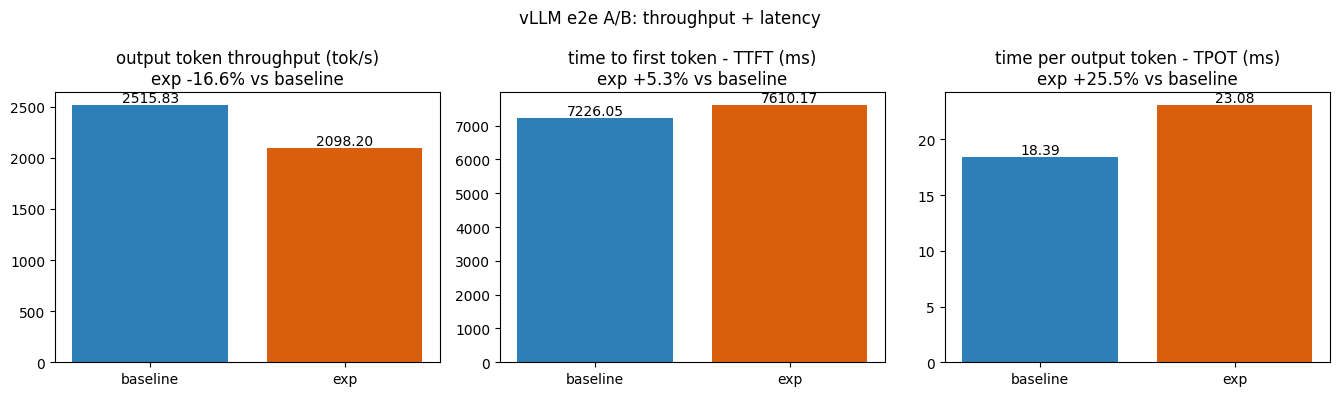

In [3]:
# vLLM e2e A/B - baseline vs exp, from the unprofiled bench arms. The three numbers
# that summarize serving: generation rate + the two latency components.
import matplotlib.pyplot as plt

e2e = df[(df["preprocessor"] == "parse_vllm") & (df["command"] == "bench") & df["num"].notna()]

# Pull one (name, statistic, unit) triple as (baseline, exp). statistic is NaN for the
# single-value throughput; "mean" for the distributional latencies.
def ab(name, stat, unit):
    m = e2e[(e2e["name"] == name) & (e2e["unit"] == unit)]
    m = m[m["statistic"].isna()] if stat is None else m[m["statistic"] == stat]
    g = m.groupby("container")["num"].first()   # one value per arm
    return g["baseline"], g["exp"]

charts = [
    ("output token throughput (tok/s)", "output_throughput", None,   "tokens_per_s"),  # e2e rate
    ("time to first token - TTFT (ms)", "ttft",              "mean", "ms"),             # prefill latency
    ("time per output token - TPOT (ms)", "tpot",            "mean", "ms"),             # decode latency
]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, (title, name, stat, unit) in zip(axes, charts):
    b, x = ab(name, stat, unit)
    bars = ax.bar(["baseline", "exp"], [b, x], color=["#2c7fb8", "#d95f0e"])
    ax.bar_label(bars, fmt="%.2f")
    ax.set_title(f"{title}\nexp {100 * (x - b) / b:+.1f}% vs baseline")
fig.suptitle("vLLM e2e A/B: throughput + latency")
plt.tight_layout()
plt.show()


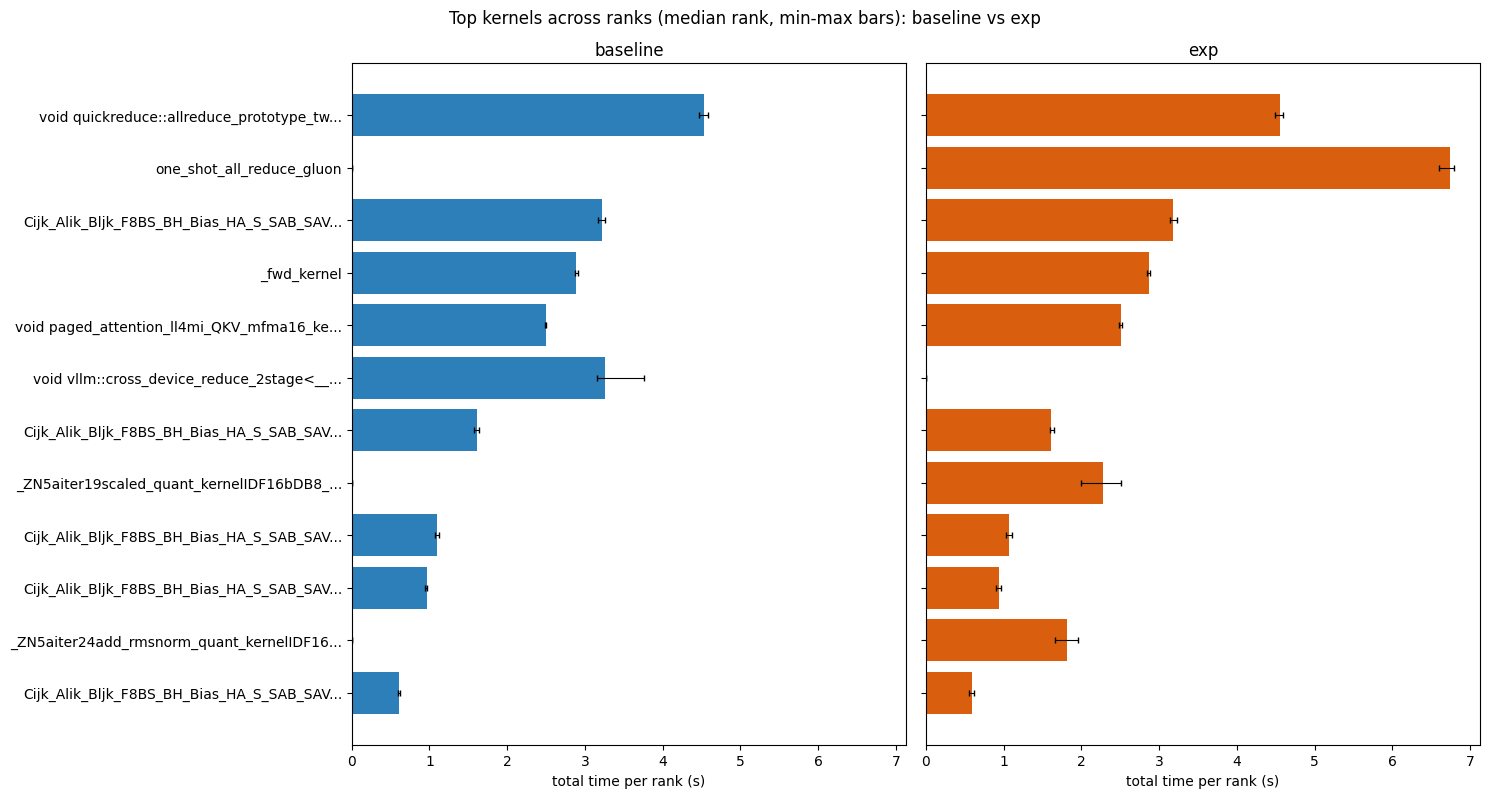

In [4]:
# Across ranks: top kernels by total time, baseline and exp in separate panels sharing
# the same x and y axes (same kernel set/order, same scale) so they compare directly.
# Bar = median across the 8 ranks, whiskers = min-max. Dumb - group kernel slices by
# name, no buckets, real names (clipped). Zero bar = kernel absent in that arm.
import matplotlib.pyplot as plt, numpy as np

NAME_LIMIT = 40
def clip(name):
    return name if len(name) <= NAME_LIMIT else name[:NAME_LIMIT] + "..."

k = df[(df["preprocessor"] == "parse_trace") & (df["grain"] == "track_slice") &
       (df["unit"] == "us") & (df["cat"] == "kernel")]
# total seconds per (arm, rank, kernel)
per = (k.groupby(["container", "rank", "name"])["num"].sum() / 1e6).reset_index()

TOPN = 12
top_names = per.groupby("name")["num"].sum().sort_values(ascending=False).head(TOPN).index.tolist()

def stats(name, arm):
    v = per[(per["name"] == name) & (per["container"] == arm)]["num"]
    return (v.median(), v.min(), v.max()) if len(v) else (0.0, 0.0, 0.0)

arms = ["baseline", "exp"]
colors = {"baseline": "#2c7fb8", "exp": "#d95f0e"}
y = np.arange(len(top_names))
fig, axes = plt.subplots(1, 2, figsize=(15, 0.55 * len(top_names) + 1.5), sharex=True, sharey=True)
for ax, arm in zip(axes, arms):
    med, lo, hi = [], [], []
    for nm in top_names:
        m, mn, mx = stats(nm, arm)
        med.append(m); lo.append(m - mn); hi.append(mx - m)
    ax.barh(y, med, color=colors[arm], xerr=[lo, hi],
            error_kw=dict(ecolor="black", lw=0.8, capsize=2))
    ax.set_title(arm)
    ax.set_xlabel("total time per rank (s)")
axes[0].set_yticks(y)
axes[0].set_yticklabels([clip(n) for n in top_names])
axes[0].invert_yaxis()   # biggest on top (shared, so both panels follow)
fig.suptitle("Top kernels across ranks (median rank, min-max bars): baseline vs exp")
plt.tight_layout()
plt.show()


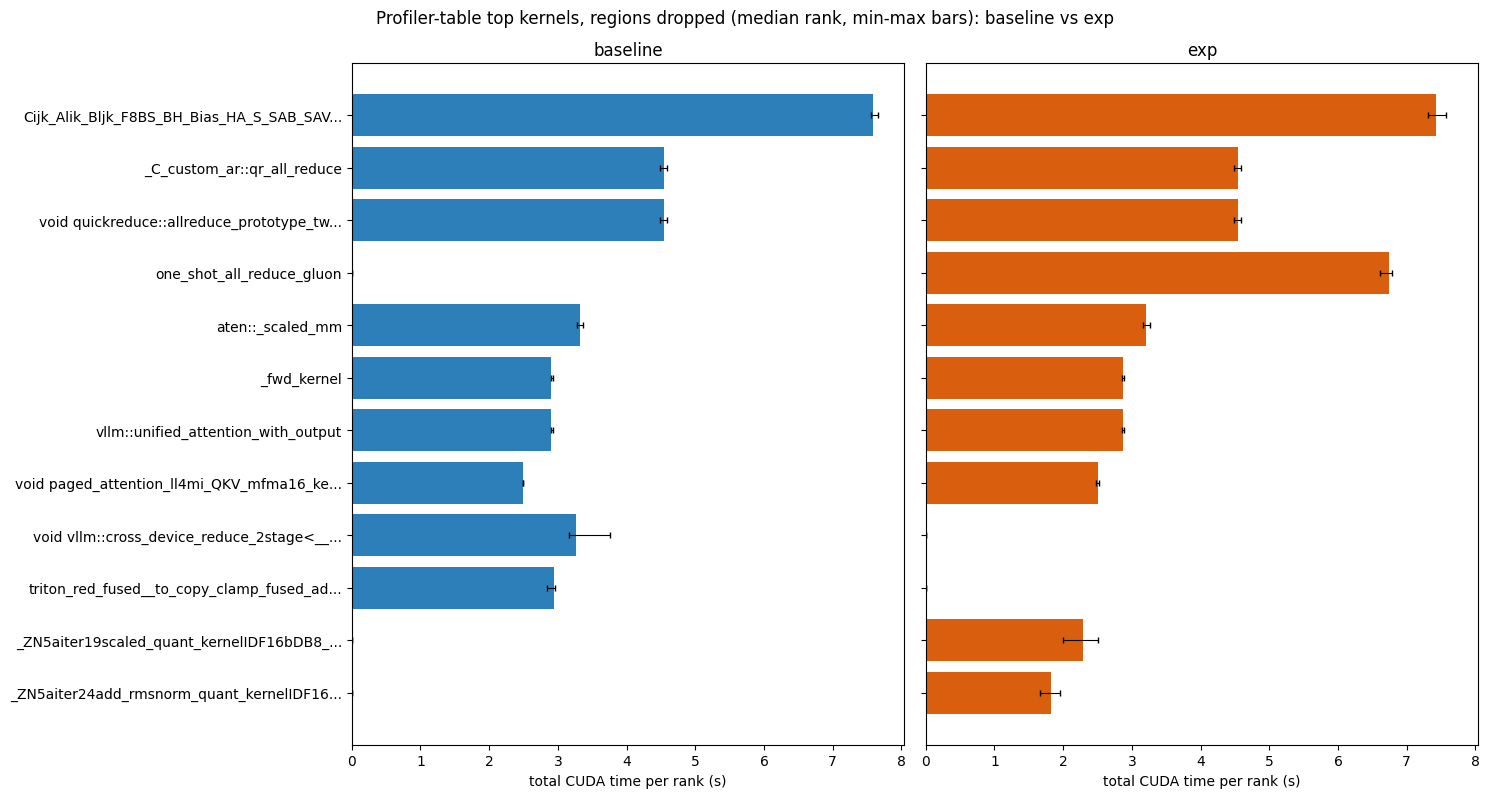

calls  per-call (us)  total (s)
kernel                    arm                                       
gluon one_shot all-reduce exp       164864           40.9       6.74
custom all-reduce 2stage  baseline  164703           19.8       3.26
quickreduce all-reduce    baseline     966         4702.5       4.54
                          exp          805         5651.5       4.55

gluon vs custom all-reduce: 40.9 vs 19.8 us/call at ~equal calls (164864 vs 164703) -> 2.1x total


In [5]:
# Cross-check from the PyTorch profiler summary tables (parse_profile), not the traces:
# each entry's total CUDA time = calls x per-call mean (the "total us" row). Same two-panel
# median/min-max view as above. We drop the cudagraph region markers (execute_context_*):
# they're host spans that CONTAIN the leaf kernels, so they double-count. (A few host
# runtime calls like hipPointerGetAttribute remain; this table isn't purely GPU kernels.)
import matplotlib.pyplot as plt, numpy as np

LIMIT = 40
def clip(name):
    return name if len(name) <= LIMIT else name[:LIMIT] + "..."

pr = df[(df["preprocessor"] == "parse_profile") & (df["statistic"].isna()) & (df["unit"] == "us")]
pr = pr[~pr["name"].str.contains("execute_context")]   # drop cudagraph region markers
perp = (pr.groupby(["container", "rank", "name"])["num"].sum() / 1e6).reset_index()

TOPN = 12
top_p = perp.groupby("name")["num"].sum().sort_values(ascending=False).head(TOPN).index.tolist()

def statp(name, arm):
    v = perp[(perp["name"] == name) & (perp["container"] == arm)]["num"]
    return (v.median(), v.min(), v.max()) if len(v) else (0.0, 0.0, 0.0)

arms = ["baseline", "exp"]
colors = {"baseline": "#2c7fb8", "exp": "#d95f0e"}
yy = np.arange(len(top_p))
fig, axes = plt.subplots(1, 2, figsize=(15, 0.55 * len(top_p) + 1.5), sharex=True, sharey=True)
for ax, arm in zip(axes, arms):
    med, lo, hi = [], [], []
    for nm in top_p:
        m, mn, mx = statp(nm, arm)
        med.append(m); lo.append(m - mn); hi.append(mx - m)
    ax.barh(yy, med, color=colors[arm], xerr=[lo, hi],
            error_kw=dict(ecolor="black", lw=0.8, capsize=2))
    ax.set_title(arm)
    ax.set_xlabel("total CUDA time per rank (s)")
axes[0].set_yticks(yy)
axes[0].set_yticklabels([clip(n) for n in top_p])
axes[0].invert_yaxis()
fig.suptitle("Profiler-table top kernels, regions dropped (median rank, min-max bars): baseline vs exp")
plt.tight_layout()
plt.show()

# All-reduce kernels: calls vs per-call vs total (same profiler table). Calls are identical
# across the 8 ranks, so the median IS the per-rank value; per-call/total vary ~1%. The
# gluon and custom all-reduce run the SAME number of calls, so the per-call gap IS the
# total gap - the kernel-level form of the correction: gluon is slower PER CALL.
def kstat(sub):
    calls = sub[sub["unit"] == "calls"].groupby("rank")["num"].first().median()
    per_call = sub[(sub["statistic"] == "mean") & (sub["unit"] == "us")].groupby("rank")["num"].first().median()
    total = sub[sub["statistic"].isna() & (sub["unit"] == "us")].groupby("rank")["num"].first().median()
    return calls, per_call, total

SPECS = [
    ("gluon one_shot all-reduce", "one_shot_all_reduce_gluon",        "exp"),
    ("custom all-reduce 2stage",  "cross_device_reduce_2stage",       "baseline"),
    ("quickreduce all-reduce",    "quickreduce::allreduce_prototype",  "baseline"),
    ("quickreduce all-reduce",    "quickreduce::allreduce_prototype",  "exp"),
]
recs = []
for label, name, cont in SPECS:
    sub = df[(df["preprocessor"] == "parse_profile") & (df["name"].str.contains(name, regex=False)) & (df["container"] == cont)]
    if not len(sub):
        continue
    calls, per_call, total = kstat(sub)
    recs.append({"kernel": label, "arm": cont, "calls": int(calls),
                 "per-call (us)": round(per_call, 1), "total (s)": round(total / 1e6, 2)})
tbl = pd.DataFrame(recs).set_index(["kernel", "arm"])
display(tbl)

g = tbl.loc[("gluon one_shot all-reduce", "exp")]
c = tbl.loc[("custom all-reduce 2stage", "baseline")]
print(f"gluon vs custom all-reduce: {g['per-call (us)']} vs {c['per-call (us)']} us/call "
      f"at ~equal calls ({int(g['calls'])} vs {int(c['calls'])}) -> {g['total (s)'] / c['total (s)']:.1f}x total")


## Summary

1. **e2e (fig 1):** exp regresses across the board. Output throughput -16.6%, TPOT +25.5%, TTFT +5.3%, duration +19.9%. TPOT is hit hardest because the all-reduce is on the decode path (every output token), while prefill/TTFT is mostly compute.
2. **kernels (figs 2 & 3):** the cause is the all-reduce. Exp's `one_shot_all_reduce_gluon` (6.7 s) replaces baseline's `cross_device_reduce_2stage` (3.25 s), roughly 2x slower, with compute unchanged. The trace (fig 2) and profiler table (fig 3) agree. Bars are the median rank and whiskers span min to max; spread is ~1%, so no rank skew.
3. **per-call (fig 3 table):** the two all-reduce kernels run the same number of calls (~165k, identical across all 8 ranks), so this is a per-call regression: gluon 40.9 us/call vs custom 19.8 us/call, roughly 2x. The earlier "gluon is faster" claim was a per-call microbench number that does not hold in the full workload.
